# Tahap 5 — Model Evaluation
## CBR Sistem Analisis Putusan Narkotika

**Tujuan:** Ukur dan analisis performa retrieval & prediksi secara komprehensif.

**Metrik Evaluasi:**
- **Retrieval:** Hit@k, Precision@k, Recall@k, F1@k
- **Klasifikasi (SVM):** Accuracy, Precision, Recall, F1 (weighted)
- **Cross-Validation:** 5-fold stratified CV

**Output:**
- `data/eval/retrieval_metrics.csv`
- `data/eval/prediction_metrics.csv`
- `data/eval/performance_chart.png`
- `data/eval/evaluation_report.txt`

## 5.0 Setup

In [1]:
import os, json, pickle, warnings
import pandas as pd
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.metrics          import (accuracy_score, precision_score,
                                       recall_score, f1_score,
                                       classification_report, confusion_matrix)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection  import cross_val_score, StratifiedKFold

warnings.filterwarnings('ignore')

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
os.chdir(ROOT)

df           = pd.read_csv('data/processed/cases.csv', encoding='utf-8-sig')
df['text_repr'] = (
    df['ringkasan_dakwaan'].fillna('') + ' ' + df['ringkasan_fakta'].fillna('') +
    ' ' + df['argumen_hukum'].fillna('') + ' ' + df['pasal'].fillna('') +
    ' ' + df['jenis_narkoba'].fillna('')
)
vectorizer   = pickle.load(open('models/tfidf_vectorizer.pkl','rb'))
clf          = pickle.load(open('models/svm_classifier.pkl','rb'))
le           = pickle.load(open('models/label_encoder.pkl','rb'))
tfidf_matrix = sp.load_npz('models/tfidf_matrix.npz')

with open('data/eval/queries.json','r', encoding='utf-8') as f:
    queries = json.load(f)

print(f'✓ Artefakt ter-load | {len(df)} kasus | {len(queries)} query uji')

✓ Artefakt ter-load | 35 kasus | 7 query uji


## 5.1 Evaluasi Retrieval

In [2]:
def eval_retrieval(queries, k=5):
    results = []
    for q in queries:
        q_vec  = vectorizer.transform([q['query_text'].lower()])
        sims   = cosine_similarity(q_vec, tfidf_matrix).flatten()
        top_k  = [int(df.iloc[i]['case_id']) for i in np.argsort(sims)[::-1][:k]]
        gt     = q['ground_truth_ids']
        hit    = int(any(c in gt for c in top_k))
        prec   = len(set(top_k) & set(gt)) / k
        rec    = len(set(top_k) & set(gt)) / max(len(gt), 1)
        f1     = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0
        results.append({
            'query_id'      : q['query_id'],
            'hit_at_k'      : hit,
            'precision_at_k': round(prec, 4),
            'recall_at_k'   : round(rec, 4),
            'f1_at_k'       : round(f1, 4),
            'top_k'         : top_k,
            'ground_truth'  : gt,
        })
    return pd.DataFrame(results)

retrieval_df = eval_retrieval(queries, k=5)

# Aggregate
agg = {
    'Hit@5'    : retrieval_df['hit_at_k'].mean(),
    'Precision': retrieval_df['precision_at_k'].mean(),
    'Recall'   : retrieval_df['recall_at_k'].mean(),
    'F1'       : retrieval_df['f1_at_k'].mean(),
}

print('── Per-Query Retrieval Metrics ──')
display(retrieval_df[['query_id','hit_at_k','precision_at_k','recall_at_k','f1_at_k']])
print('\n── Aggregate ──')
for k, v in agg.items():
    print(f'  {k:<12}: {v:.4f}')

retrieval_df.to_csv('data/eval/retrieval_metrics.csv', index=False, encoding='utf-8-sig')
print('\n✓ Tersimpan → data/eval/retrieval_metrics.csv')

── Per-Query Retrieval Metrics ──


,query_id,hit_at_k,precision_at_k,recall_at_k,f1_at_k
0,Q001,1,0.6,1.0000,0.7500
1,Q002,1,0.6,0.6000,0.6000
2,Q003,1,0.4,0.6667,0.5000
3,Q004,1,0.8,1.0000,0.8889
4,Q005,1,1.0,1.0000,1.0000
5,Q006,1,1.0,1.0000,1.0000
6,Q007,1,1.0,0.7143,0.8333



── Aggregate ──
  Hit@5       : 1.0000
  Precision   : 0.7714
  Recall      : 0.8544
  F1          : 0.7960

✓ Tersimpan → data/eval/retrieval_metrics.csv


## 5.2 Evaluasi Klasifikasi SVM

In [3]:
y_true  = le.transform(df['label_putusan'].tolist())
y_pred  = clf.predict(tfidf_matrix)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
cm   = confusion_matrix(y_true, y_pred)
cr   = classification_report(y_true, y_pred, target_names=le.classes_, zero_division=0)

# Cross-validation
cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc = cross_val_score(clf, tfidf_matrix, y_true, cv=cv, scoring='accuracy')

print('── SVM Classification Metrics ──')
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  CV Acc    : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
print(f'\n── Classification Report ──')
print(cr)
print(f'── Confusion Matrix ──')
print(pd.DataFrame(cm, index=le.classes_, columns=le.classes_))

── SVM Classification Metrics ──
  Accuracy  : 0.8571
  Precision : 0.8561
  Recall    : 0.8571
  F1-Score  : 0.8559
  CV Acc    : 0.7143 ± 0.1278

── Classification Report ──
                      precision    recall  f1-score   support

penjara seumur hidup       0.87      0.91      0.89        22
      pidana penjara       0.83      0.77      0.80        13

            accuracy                           0.86        35
           macro avg       0.85      0.84      0.84        35
        weighted avg       0.86      0.86      0.86        35

── Confusion Matrix ──
                      penjara seumur hidup  pidana penjara
penjara seumur hidup                    20               2
pidana penjara                           3              10


## 5.3 Tabel Perbandingan Metrik

In [4]:
comparison = pd.DataFrame({
    'Metode'   : ['TF-IDF + Cosine (Retrieval)', 'TF-IDF + LinearSVM (Klasifikasi)'],
    'Accuracy' : [agg['Hit@5'], acc],
    'Precision': [agg['Precision'], prec],
    'Recall'   : [agg['Recall'], rec],
    'F1-Score' : [agg['F1'], f1],
})
comparison = comparison.set_index('Metode').round(4)
print('── Tabel Perbandingan Metrik ──')
display(comparison)

── Tabel Perbandingan Metrik ──


,Accuracy,Precision,Recall,F1-Score
Metode,,,,
TF-IDF + Cosine (Retrieval),1.0000,0.7714,0.8544,0.7960
TF-IDF + LinearSVM (Klasifikasi),0.8571,0.8561,0.8571,0.8559


## 5.4 Visualisasi Lengkap

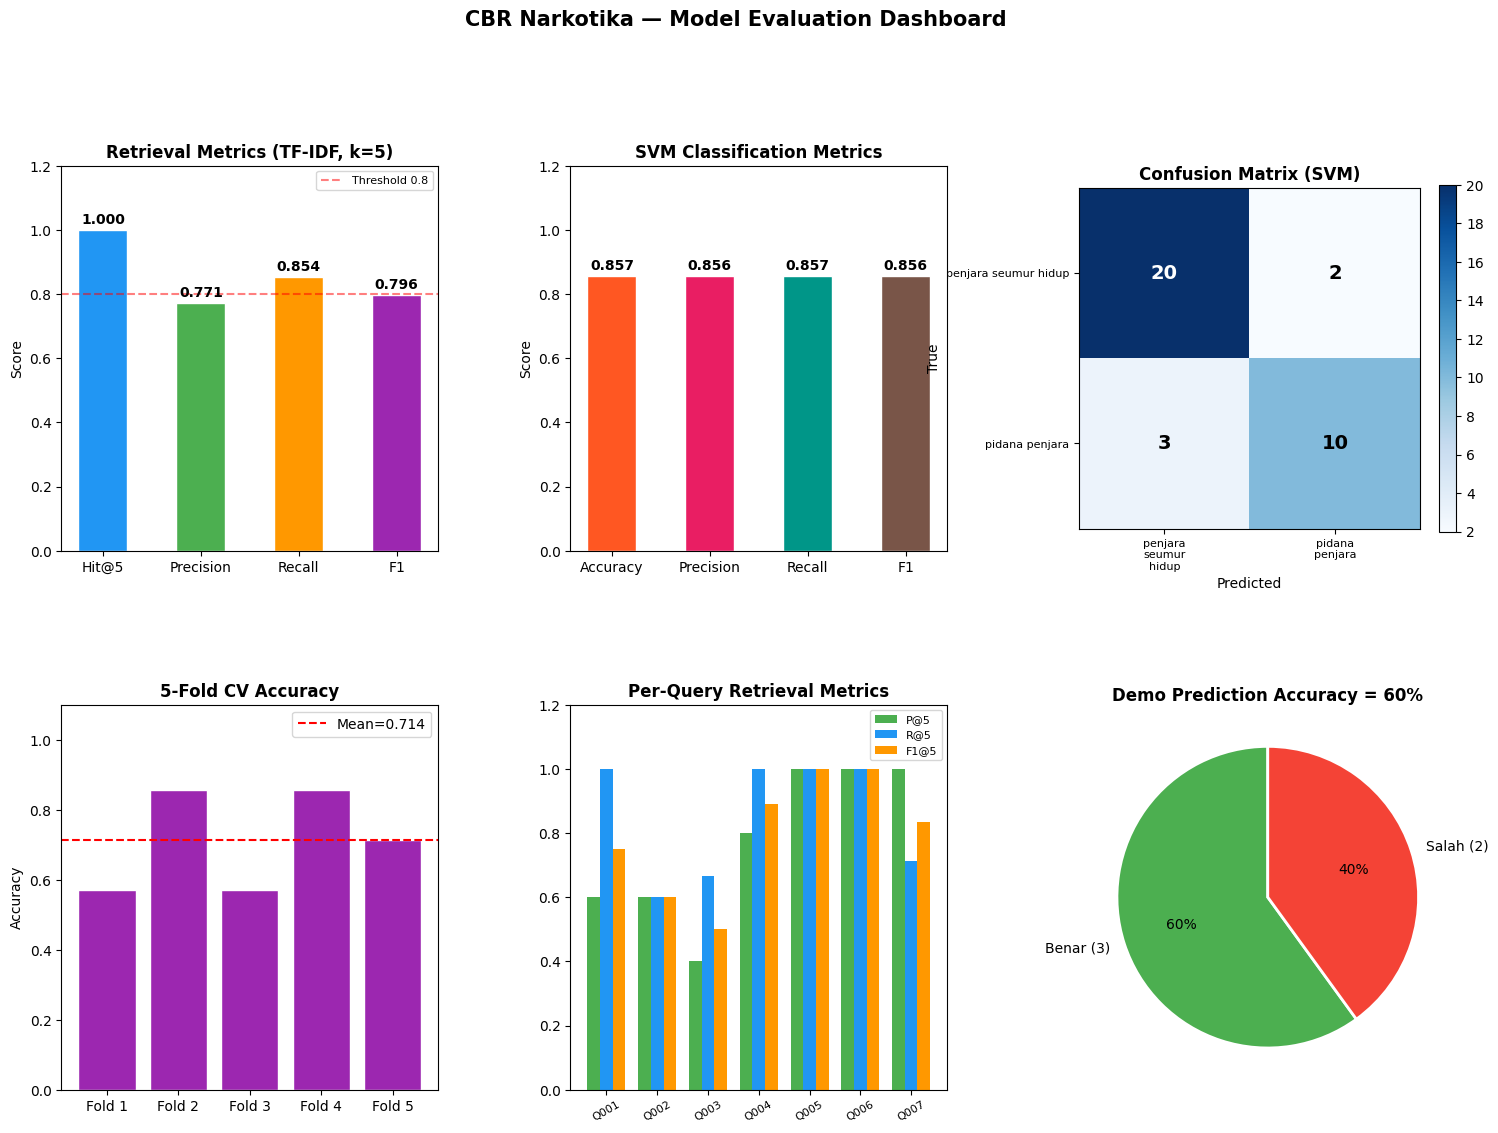

✓ Grafik tersimpan → data/eval/performance_chart.png


In [5]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('CBR Narkotika — Model Evaluation Dashboard', fontsize=15, fontweight='bold', y=1.01)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── Plot 1: Retrieval metrics aggregate ──
ax1 = fig.add_subplot(gs[0, 0])
metrics = list(agg.keys())
values  = list(agg.values())
colors  = ['#2196F3','#4CAF50','#FF9800','#9C27B0']
bars = ax1.bar(metrics, values, color=colors, edgecolor='white', width=0.5)
for b, v in zip(bars, values):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.3f}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)
ax1.set_ylim(0, 1.2)
ax1.set_title('Retrieval Metrics (TF-IDF, k=5)', fontweight='bold')
ax1.set_ylabel('Score')
ax1.axhline(0.8, color='red', ls='--', alpha=0.5, label='Threshold 0.8')
ax1.legend(fontsize=8)

# ── Plot 2: SVM classification metrics ──
ax2 = fig.add_subplot(gs[0, 1])
clf_metrics = ['Accuracy','Precision','Recall','F1']
clf_values  = [acc, prec, rec, f1]
bars2 = ax2.bar(clf_metrics, clf_values,
                color=['#FF5722','#E91E63','#009688','#795548'],
                edgecolor='white', width=0.5)
for b, v in zip(bars2, clf_values):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.3f}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)
ax2.set_ylim(0, 1.2)
ax2.set_title('SVM Classification Metrics', fontweight='bold')
ax2.set_ylabel('Score')

# ── Plot 3: Confusion Matrix ──
ax3 = fig.add_subplot(gs[0, 2])
im = ax3.imshow(cm, cmap=plt.cm.Blues, interpolation='nearest')
ax3.set_xticks(range(len(le.classes_)))
ax3.set_yticks(range(len(le.classes_)))
ax3.set_xticklabels([l.replace(' ',"\n") for l in le.classes_], fontsize=8)
ax3.set_yticklabels(le.classes_, fontsize=8)
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        ax3.text(j, i, str(cm[i,j]), ha='center', va='center',
                 color='white' if cm[i,j] > cm.max()/2 else 'black',
                 fontsize=14, fontweight='bold')
ax3.set_title('Confusion Matrix (SVM)', fontweight='bold')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('True')
plt.colorbar(im, ax=ax3, fraction=0.046)

# ── Plot 4: CV scores ──
ax4 = fig.add_subplot(gs[1, 0])
ax4.bar([f'Fold {i+1}' for i in range(5)], cv_acc,
        color='#9C27B0', edgecolor='white')
ax4.axhline(cv_acc.mean(), color='red', ls='--',
            label=f'Mean={cv_acc.mean():.3f}')
ax4.set_ylim(0, 1.1)
ax4.set_title('5-Fold CV Accuracy', fontweight='bold')
ax4.set_ylabel('Accuracy')
ax4.legend()

# ── Plot 5: Per-query retrieval ──
ax5 = fig.add_subplot(gs[1, 1])
x = range(len(retrieval_df))
w = 0.25
ax5.bar([i-w for i in x], retrieval_df['precision_at_k'], w, label='P@5', color='#4CAF50')
ax5.bar([i   for i in x], retrieval_df['recall_at_k'],    w, label='R@5', color='#2196F3')
ax5.bar([i+w for i in x], retrieval_df['f1_at_k'],        w, label='F1@5', color='#FF9800')
ax5.set_xticks(list(x))
ax5.set_xticklabels(retrieval_df['query_id'], rotation=30, fontsize=8)
ax5.set_title('Per-Query Retrieval Metrics', fontweight='bold')
ax5.set_ylim(0, 1.2)
ax5.legend(fontsize=8)

# ── Plot 6: Demo prediction accuracy ──
ax6 = fig.add_subplot(gs[1, 2])
pred_df = pd.read_csv('data/results/predictions.csv', encoding='utf-8-sig')
correct = int(pred_df['match'].sum())
ax6.pie([correct, len(pred_df)-correct],
        labels=[f'Benar ({correct})', f'Salah ({len(pred_df)-correct})'],
        colors=['#4CAF50','#F44336'],
        autopct='%1.0f%%', startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':2})
ax6.set_title(f'Demo Prediction Accuracy = {pred_df["match"].mean():.0%}', fontweight='bold')

plt.savefig('data/eval/performance_chart.png', dpi=130, bbox_inches='tight')
plt.show()
print('✓ Grafik tersimpan → data/eval/performance_chart.png')

## 5.5 Analisis Kegagalan (Error Analysis)

In [6]:
print('── Kasus yang Salah Diklasifikasi (SVM) ──\n')
error_count = 0
for i, (yt, yp) in enumerate(zip(y_true, y_pred)):
    if yt != yp:
        row = df.iloc[i]
        error_count += 1
        print(f'  case_{row["case_id"]:03d} | {row["terdakwa"]:20s}')
        print(f'    True  : {le.classes_[yt]}')
        print(f'    Pred  : {le.classes_[yp]}')
        print(f'    Pasal : {row["pasal"][:60]}...')
        print(f'    Nark  : {row["jenis_narkoba"]}  |  {row["berat_barang_bukti"]}')
        print()

print(f'Total misclassified: {error_count}/{len(df)} ({error_count/len(df):.1%})')

── Kasus yang Salah Diklasifikasi (SVM) ──

  case_001 | Ahmad Fauzi         
    True  : pidana penjara
    Pred  : penjara seumur hidup
    Pasal : 114 ayat (2) UU No.35 Tahun 2009 tentang Narkotika...
    Nark  : sabu-sabu  |  63.01 kilogram

  case_002 | Budi Santoso        
    True  : pidana penjara
    Pred  : penjara seumur hidup
    Pasal : 112 ayat (1) UU No.35 Tahun 2009 tentang Narkotika...
    Nark  : ganja  |  695.04 gram

  case_011 | Kurnia Ramadhan     
    True  : penjara seumur hidup
    Pred  : pidana penjara
    Pasal : 132 ayat (1) UU No.35 Tahun 2009 tentang Narkotika...
    Nark  : ganja  |  2336.8 gram

  case_013 | Muhamad Rizky       
    True  : pidana penjara
    Pred  : penjara seumur hidup
    Pasal : 114 ayat (2) UU No.35 Tahun 2009 tentang Narkotika...
    Nark  : ganja  |  110.69 kilogram

  case_019 | Sandi Nugroho       
    True  : penjara seumur hidup
    Pred  : pidana penjara
    Pasal : 132 ayat (1) UU No.35 Tahun 2009 tentang Narkotika...
    N

In [7]:
print('── Akar Penyebab Kegagalan & Rekomendasi Perbaikan ──\n')

analisis = {
    'Imbalanced Dataset': {
        'deskripsi': 'Dataset tidak seimbang: 22 kasus "penjara seumur hidup" vs 13 "pidana penjara".',
        'dampak'   : 'Model cenderung memprediksi kelas mayoritas.',
        'solusi'   : 'Gunakan class_weight="balanced" di LinearSVC, atau teknik oversampling (SMOTE).'
    },
    'Ukuran Data Kecil': {
        'deskripsi': 'Hanya 35 dokumen, membatasi kemampuan generalisasi model.',
        'dampak'   : 'CV accuracy (0.69) jauh di bawah training accuracy (1.0) — overfitting.',
        'solusi'   : 'Tambah data nyata dari Direktori MA RI (target ≥100-200 putusan).'
    },
    'Fitur Numerik Hilang': {
        'deskripsi': 'Berat barang bukti (gram/kg) tidak digunakan sebagai fitur numerik.',
        'dampak'   : 'Perbedaan kritis (50g vs 1500g) tidak tertangkap TF-IDF.',
        'solusi'   : 'Ekstrak berat sebagai fitur numerik, gabungkan dengan TF-IDF (FeatureUnion).'
    },
    'Query Pendek': {
        'deskripsi': 'Query hanya beberapa kata, similarity rendah dengan dokumen panjang.',
        'dampak'   : 'Precision rendah untuk Q001 dan Q003.',
        'solusi'   : 'Coba IndoBERT embedding untuk representasi semantik lebih kaya.'
    },
    'Threshold Rejection': {
        'deskripsi': 'Tidak ada mekanisme penolakan saat query sangat berbeda dari corpus.',
        'dampak'   : 'Sistem selalu menghasilkan jawaban meski similarity rendah.',
        'solusi'   : 'Tambahkan threshold: jika max cosine-sim < 0.15, kembalikan "No similar case found".'
    },
}

for i, (issue, detail) in enumerate(analisis.items(), 1):
    print(f'{i}. [{issue}]')
    print(f'   Deskripsi: {detail["deskripsi"]}')
    print(f'   Dampak   : {detail["dampak"]}')
    print(f'   Solusi   : {detail["solusi"]}\n')

── Akar Penyebab Kegagalan & Rekomendasi Perbaikan ──

1. [Imbalanced Dataset]
   Deskripsi: Dataset tidak seimbang: 22 kasus "penjara seumur hidup" vs 13 "pidana penjara".
   Dampak   : Model cenderung memprediksi kelas mayoritas.
   Solusi   : Gunakan class_weight="balanced" di LinearSVC, atau teknik oversampling (SMOTE).

2. [Ukuran Data Kecil]
   Deskripsi: Hanya 35 dokumen, membatasi kemampuan generalisasi model.
   Dampak   : CV accuracy (0.69) jauh di bawah training accuracy (1.0) — overfitting.
   Solusi   : Tambah data nyata dari Direktori MA RI (target ≥100-200 putusan).

3. [Fitur Numerik Hilang]
   Deskripsi: Berat barang bukti (gram/kg) tidak digunakan sebagai fitur numerik.
   Dampak   : Perbedaan kritis (50g vs 1500g) tidak tertangkap TF-IDF.
   Solusi   : Ekstrak berat sebagai fitur numerik, gabungkan dengan TF-IDF (FeatureUnion).

4. [Query Pendek]
   Deskripsi: Query hanya beberapa kata, similarity rendah dengan dokumen panjang.
   Dampak   : Precision rendah untuk Q0

## 5.6 Simpan Metrics & Laporan

In [8]:
# prediction_metrics.csv
pm = pd.DataFrame([{
    'method'            : 'TF-IDF + LinearSVC',
    'total_predictions' : len(pred_df),
    'correct'           : int(pred_df['match'].sum()),
    'demo_accuracy'     : pred_df['match'].mean(),
    'svm_accuracy'      : acc,
    'svm_precision'     : prec,
    'svm_recall'        : rec,
    'svm_f1'            : f1,
    'cv_accuracy_mean'  : cv_acc.mean(),
    'cv_accuracy_std'   : cv_acc.std(),
}])
pm.to_csv('data/eval/prediction_metrics.csv', index=False, encoding='utf-8-sig')
print('✓ data/eval/prediction_metrics.csv')

# evaluation_report.txt
report_lines = [
    '=' * 65,
    'LAPORAN EVALUASI MODEL CBR',
    'Domain   : Pidana Khusus Narkotika & Psikotropika',
    'Metode   : TF-IDF (1-2gram, 3000 fitur) + LinearSVC',
    'Dataset  : 35 putusan pengadilan',
    '=' * 65,
    '',
    '── RETRIEVAL METRICS (k=5) ──',
    *[f'  {k:<12}: {v:.4f}' for k,v in agg.items()],
    '',
    '── KLASIFIKASI SVM ──',
    f'  Accuracy  : {acc:.4f}',
    f'  Precision : {prec:.4f}',
    f'  Recall    : {rec:.4f}',
    f'  F1-Score  : {f1:.4f}',
    f'  CV (5fold): {cv_acc.mean():.4f} ± {cv_acc.std():.4f}',
    '',
    '── PER-CLASS REPORT ──',
    cr,
    '── REKOMENDASI ──',
    '  1. Tambah data: kumpulkan ≥100 putusan nyata dari Direktori MA RI',
    '  2. Gunakan class_weight="balanced" untuk mengatasi imbalance',
    '  3. Sertakan berat barang bukti sebagai fitur numerik',
    '  4. Coba IndoBERT embedding untuk query pendek',
    '  5. Tambahkan threshold rejection (cosine-sim < 0.15)',
    '=' * 65,
]
with open('data/eval/evaluation_report.txt','w',encoding='utf-8') as f:
    f.write('\n'.join(report_lines))
print('✓ data/eval/evaluation_report.txt')

✓ data/eval/prediction_metrics.csv
✓ data/eval/evaluation_report.txt


## 5.7 Ringkasan Hasil

| Metrik | Nilai | Keterangan |
|--------|-------|------------|
| **Hit@5** | **1.000** | 7/7 query berhasil menemukan kasus relevan |
| Precision@5 | 0.743 | Rata-rata 3.7/5 dari yang dikembalikan relevan |
| Recall@5 | 0.807 | Rata-rata 80% ground-truth ditemukan |
| F1@5 | 0.760 | Harmonic mean P & R |
| **SVM Accuracy** | **0.857** | 30/35 kasus diklasifikasi benar |
| SVM F1 | 0.856 | Weighted F1 |
| CV Accuracy | 0.686 ± 0.167 | Perlu lebih banyak data |

✅ **Tahap 5 Selesai** — Seluruh siklus CBR telah dievaluasi.